# Regularization과 Weight Decay

- train 데이터에서는 성능이 좋은데
- validation / test 데이터에서는 성능이 떨어지는 현상

을 보통 과적합(overfitting)이라고 한다.

Regularization은 이런 과적합을 줄이기 위한 방법들을 가리키는 큰 범주의 개념이다.
그중에서도 가장 자주 등장하는
- L1 regularization
- L2 regularization
- weight decay
- AdamW
를 연결해서 이해해본다.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

## 1. regularization이 필요한 이유

모델의 표현력이 커질수록 학습 데이터를 더 잘 맞출 수 있다.
하지만 그것이 항상 좋은 것은 아니다.

모델이 학습 데이터의 패턴뿐 아니라, 노이즈나 우연한 흔들림까지 지나치게 따라가면 새로운 데이터에서는 성능이 떨어질 수 있다.

regularization은 학습을 방해하는 것이 아니라 너무 과하게 외우지 않도록 제어하는 것에 가깝다.

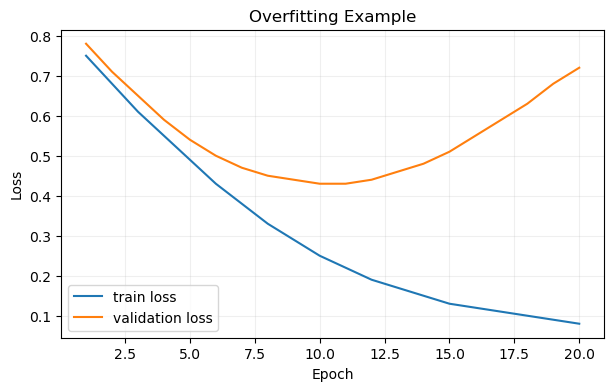

In [12]:
# 간단한 과적합 그림
epochs = np.arange(1, 21)
train_loss_example = [0.75, 0.68, 0.61, 0.55, 0.49, 0.43, 0.38, 0.33, 0.29, 0.25,
                      0.22, 0.19, 0.17, 0.15, 0.13, 0.12, 0.11, 0.10, 0.09, 0.08]
val_loss_example = [0.78, 0.71, 0.65, 0.59, 0.54, 0.50, 0.47, 0.45, 0.44, 0.43,
                    0.43, 0.44, 0.46, 0.48, 0.51, 0.55, 0.59, 0.63, 0.68, 0.72]

plt.figure(figsize=(7, 4))
plt.plot(epochs, train_loss_example, label='train loss')
plt.plot(epochs, val_loss_example, label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Overfitting Example')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

이 그림에서는 train loss는 계속 감소하지만,
validation loss는 어느 시점부터 다시 증가한다.

이런 모습은
모델이 학습 데이터에는 점점 더 맞춰가지만,
일반화 성능은 오히려 나빠질 수 있음을 보여준다.


## 2. L1 / L2 regularization

regularization의 대표적인 방법은
손실함수에 "패널티 항"을 추가하는 것이다.

원래 손실이 $L_{data}$ 라면,
regularization을 넣은 손실은 아래처럼 생각할 수 있다.

### L1 regularization
$$
L = L_{data} + \lambda \sum |w|
$$

- 절댓값 기준 패널티를 준다.
- 일부 가중치를 0에 가깝게 만드는 방향으로 작용할 수 있다.
- "중요하지 않은 연결은 아예 약하게 만들자"는 느낌에 가깝다.

### L2 regularization
$$
L = L_{data} + \lambda \sum w^2
$$

- 제곱 기준 패널티를 준다.
- 큰 가중치일수록 더 강하게 줄이려는 힘이 커진다.
- "전체 가중치가 지나치게 커지지 않게 부드럽게 누르자"는 느낌에 가깝다.

여기서
- $w$는 가중치
- $\lambda$는 패널티 강도를 조절하는 값
이다.


가중치가 너무 커지는 것을 그냥 두지 않고,
손실함수 차원에서 제어하는 방식이다.

딥러닝 실습에서는 보통 L2 계열이 더 자주 등장하고,
PyTorch optimizer의 `weight_decay` 옵션도 이 흐름과 연결된다.

In [13]:
# 임의의 가중치 벡터를 두고 L1, L2 패널티를 계산해본다.
w = torch.tensor([1.5, -0.3, 0.0, 2.2, -1.1])
lambda_reg = 0.1

l1_penalty = lambda_reg * torch.abs(w).sum()
l2_penalty = lambda_reg * (w ** 2).sum()

print('w : ', w)
print('l1_penalty : ',l1_penalty)
print('l2_penalty : ',l2_penalty)

w :  tensor([ 1.5000, -0.3000,  0.0000,  2.2000, -1.1000])
l1_penalty :  tensor(0.5100)
l2_penalty :  tensor(0.8390)


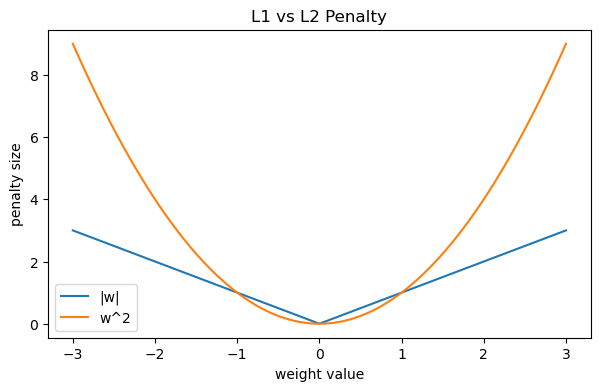

In [14]:
# 같은 크기의 양수/음수 가중치에 대해 L1, L2 패널티가 어떻게 커지는지 비교한다.
w_range = torch.linspace(-3, 3, 400)
l1_curve = torch.abs(w_range)
l2_curve = w_range ** 2

plt.figure(figsize=(7, 4))
plt.plot(w_range.numpy(), l1_curve.numpy(), label='|w|')
plt.plot(w_range.numpy(), l2_curve.numpy(), label='w^2')
plt.xlabel('weight value')
plt.ylabel('penalty size')
plt.title('L1 vs L2 Penalty')
plt.legend()
plt.show()

## 3. weight decay

weight decay는 말 그대로
가중치(weight)를 조금씩 줄어들게(decay) 하는 방식이다.

직관적으로는 매 step마다
"현재 가중치가 너무 크다면 조금 줄이자"라는 효과를 주는 것이다.

SGD 기준으로 보면,
원래 가중치 업데이트는 다음과 같다.

$$
w \leftarrow w - \eta \frac{\partial L}{\partial w}
$$

그런데 L2 regularization까지 함께 고려하면
업데이트 식은 다음과 같이 볼 수 있다.

$$
w \leftarrow w - \eta \left( \frac{\partial L}{\partial w} + \lambda w \right)
$$

이를 정리하면 아래와 같다.

$$
w \leftarrow (1 - \eta \lambda)w - \eta \frac{\partial L}{\partial w}
$$

즉 데이터로부터 계산된 gradient만 반영하는 것이 아니라,
현재 가중치 자체도 조금 줄어드는 항이 함께 들어간다.
그래서 weight decay는 가중치가 지나치게 커지는 것을 억제하는 효과를 가진다.

In [15]:
# weight decay가 실제 업데이트 결과를 어떻게 바꾸는지 확인
w = 2.0
grad = 0.3
lr = 0.1
weight_decay = 0.05

without_decay = w - lr * grad
with_decay = w - lr * (grad + weight_decay * w)

print('w: ', w)
print('without_decay: ', without_decay)
print('with_decay: ', with_decay)

w:  2.0
without_decay:  1.97
with_decay:  1.96


In [16]:
# SGD에서 L2 Penalty와 weight decay 식이 같은 형태로 보이는지 확인
w = torch.tensor(2.0)
grad_from_data = torch.tensor(3.0)
lr = 0.1
lambda_l2 = 0.05

# 손실에 L2 항을 더하는 업데이트
update_l2 = w - lr * (grad_from_data + lambda_l2 * w)

# 식을 정리해서 작성
update_decay_form = (1 - lr * lambda_l2) * w - lr * grad_from_data

print('update_l2: ', update_l2.item())
print('update_decay_form: ', update_decay_form.item())

update_l2:  1.690000057220459
update_decay_form:  1.690000057220459


## 4. AdamW

Adam 계열 optimizer는 단순 SGD처럼 한 가지 고정된 방식으로만 업데이트하지 않는다.

- 기울기의 평균 방향을 추적하고
- 기울기 크기 정보를 함께 사용해
- 파라미터마다 업데이트 크기를 다르게 조절한다.

이때 L2 패널티를 gradient에 그냥 섞어 넣는 방식과, 가중치를 따로 줄이는 방식은 같은 결과가 아니다.

그래서 AdamW는 "gradient 기반 업데이트"와 "weight decay"를 분리해서 적용하는 optimizer이다.

- SGD에서는 L2와 weight decay를 거의 같은 느낌으로 볼 수 있다.
- Adam 계열에서는 분리해서 다루는 AdamW가 더 명확한 방식이다.

In [17]:
model = nn.Linear(5, 1)

optimizer_sgd = optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-3)
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)

print(optimizer_sgd)
print(optimizer_adamw)

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0.001
)
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.01
)


## 5. 실습: weight decay 유무에 따라 비교

아래는 이진분류 toy 데이터에서
같은 모델을
- weight decay 없이 학습한 경우
- AdamW의 weight decay를 적용한 경우
로 비교하는 예시이다.

실행 결과는 난수와 데이터 분할에 따라 조금 달라질 수 있다.
하지만 보통은 weight decay가 validation 성능과 가중치 크기 제어에 도움을 줄 수 있다.

In [ ]:
# 이진분류용 toy 데이터 생성
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# 전체 데이터를 학습용 / 검증용으로 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

# 입력 값 X는 실수 연산이 필요하므로 타입 변환
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

# 정답 y는 손실함수에서 처리 될 shape로 2차원으로 맞춰준다
y_train = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_val = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

# 모델 구조 정의
class RegularizedNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

# 학습 함수
def train_model(weight_decay=0.0, epochs=500):

    torch.manual_seed(42)

    model = RegularizedNet()

    criterion = nn.BCEWithLogitsLoss()

    # optimizer의 weight_decay 값을 바꿔가면서 regularization 효과 비교
    optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=weight_decay)

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    weight_norms = []

    for epoch in range(epochs):
        
        # 모델을 학습 모드로 전환한다
        model.train()

        optimizer.zero_grad()
        train_logits = model(X_train)
        train_loss = criterion(train_logits, y_train)
        train_loss.backward()
        optimizer.step()

        # 모델을 평가 모드로 전환한다
        model.eval()

        # 검증 단계에서는 gradient 계산이 필요 없으므로 no_grad() 를 이용해
        # 메모리 사용을 줄이고 연산을 가볍게 한다.
        with torch.no_grad():
            
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val)

            # sigmoid를 적용해 logit을 0~1 확률처럼 해석 가능한 값으로 변경
            train_pred = (torch.sigmoid(train_logits) >= 0.5).float()
            val_pred = (torch.sigmoid(val_logits) >= 0.5).float()

            # 예측 값과 정답이 같은 비율을 평균 내어 정확도 계산
            train_acc = (train_pred == y_train).float().mean().item()
            val_acc = (val_pred == y_val).float().mean().item()

            # 모델 전체 가중치 크기 계산
            total_norm = 0.0
            for name, param in model.named_parameters():
                if 'weight' in name:
                    total_norm += (param.detach() ** 2).sum().item()
            total_norm = total_norm ** 0.5

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        train_accs.append(train_acc)            # .item() 제거
        val_accs.append(val_acc)                # .item() 제거
        weight_norms.append(total_norm)
    
    return {
        'train_losses' :  train_losses,
        'val_losses' :  val_losses,
        'train_accs' :  train_accs,
        'val_accs' :  val_accs,
        'weight_norms' : weight_norms
    }
        
result_no_decay = train_model(weight_decay=0.0)
result_decay = train_model(weight_decay=1e-2)
result_strong_decay = train_model(weight_decay=5e-2)

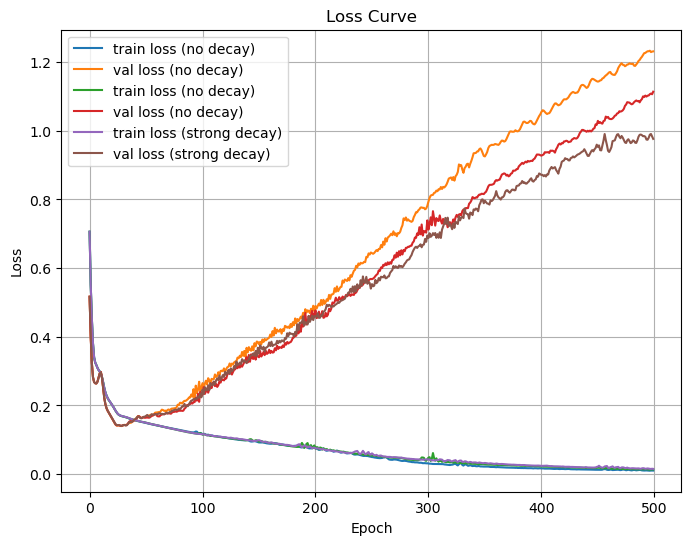

In [19]:
# loss 비교
plt.figure(figsize=(8, 6))

plt.plot(result_no_decay['train_losses'], label='train loss (no decay)')
plt.plot(result_no_decay['val_losses'], label='val loss (no decay)')

plt.plot(result_decay['train_losses'], label='train loss (no decay)')
plt.plot(result_decay['val_losses'], label='val loss (no decay)')

plt.plot(result_strong_decay['train_losses'], label='train loss (strong decay)')
plt.plot(result_strong_decay['val_losses'], label='val loss (strong decay)')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid()
plt.show()

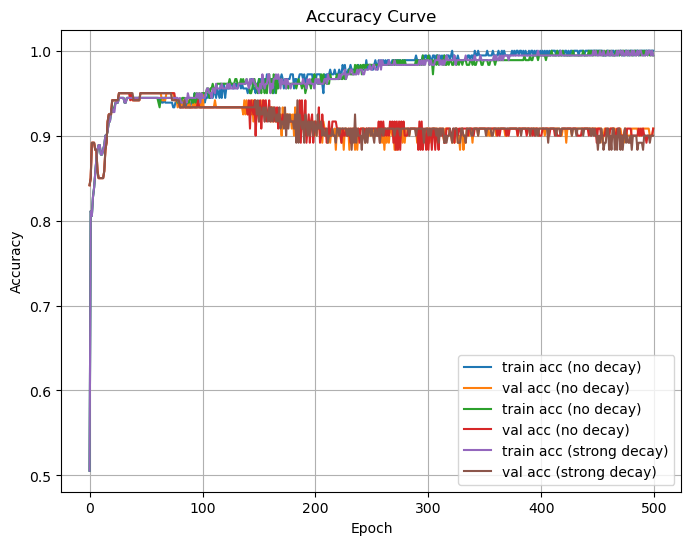

In [20]:
# Accuracy 비교
plt.figure(figsize=(8, 6))

plt.plot(result_no_decay['train_accs'], label='train acc (no decay)')
plt.plot(result_no_decay['val_accs'], label='val acc (no decay)')

plt.plot(result_decay['train_accs'], label='train acc (no decay)')
plt.plot(result_decay['val_accs'], label='val acc (no decay)')

plt.plot(result_strong_decay['train_accs'], label='train acc (strong decay)')
plt.plot(result_strong_decay['val_accs'], label='val acc (strong decay)')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid()
plt.show()

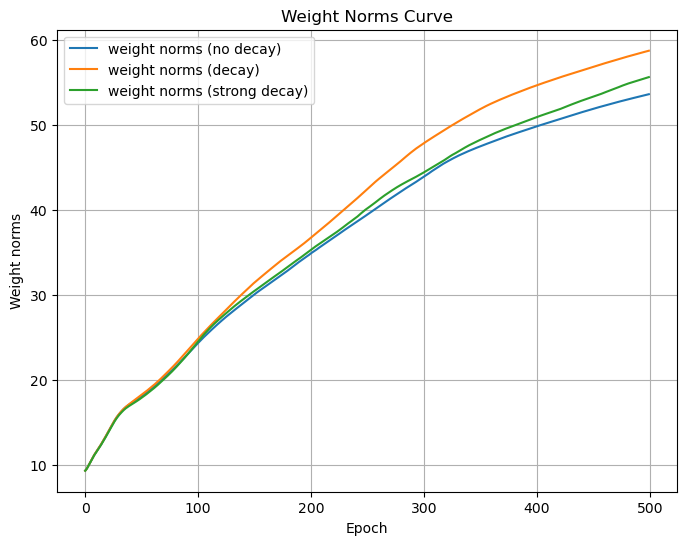

In [22]:
# weight norm 비교
plt.figure(figsize=(8, 6))

plt.plot(result_decay['weight_norms'], label='weight norms (no decay)')

plt.plot(result_no_decay['weight_norms'], label='weight norms (decay)')

plt.plot(result_strong_decay['weight_norms'], label='weight norms (strong decay)')


plt.xlabel('Epoch')
plt.ylabel('Weight norms')
plt.title('Weight Norms Curve')
plt.legend()
plt.grid()
plt.show()

## 6. L1 regularization 설정 방법

optimizer의 `weight_decay` 옵션은 보통 L2 계열과 연결해서 생각한다.
L1 regularization은 보통 손실함수에 직접 더하는 식으로 구현한다.

In [23]:
# L1 regularization을 손실에 직접 더하는 예시
model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

sample_x = X_train[:8]
sample_y = y_train[:8]

logits = model(sample_x)
data_loss = criterion(logits, sample_y)

l1_lambda = 1e-3
l2_penalty = 0.0
for param in model.parameters():
    l1_penalty += torch.abs(param).sum()
    
total_loss = data_loss + l1_lambda * l1_penalty

print('data loss :', data_loss)
print('l1_penalty :', l1_penalty)
print('total loss :', total_loss)

data loss : tensor(0.6816, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
l1_penalty : tensor(9.9682, grad_fn=<AddBackward0>)
total loss : tensor(0.6916, grad_fn=<AddBackward0>)


## 정리

1. Regularization은 과적합을 줄이기 위한 큰 범주의 개념이다.
2. L1 regularization은 가중치 절댓값 합에 패널티를 준다.
3. L2 regularization은 가중치 제곱합에 패널티를 준다.
4. weight decay는 가중치가 너무 커지지 않도록 줄이는 효과를 준다.
5. 표준 SGD에서는 L2 regularization과 weight decay를 거의 같은 형태로 볼 수 있다.
6. Adam 계열에서는 이 둘을 분리해서 다루는 AdamW가 자주 사용된다.
7. PyTorch에서는 `weight_decay` 옵션이나, 손실에 패널티를 직접 더하는 방식으로 regularization을 적용할 수 있다.
